# Part 0 — Setup & Imports

This notebook accompanies the written report for the EMIF group project and is organized to reproduce all results in a transparent, step-by-step manner. The research question is: **"How do oil price increases transmit across asset classes — equities, government bonds, credit markets, and gold — and can we build a forecasting framework to anticipate these multi-asset effects?"**

The notebook covers data loading, descriptive analysis, stationarity and cointegration tests, VAR estimation, structural analysis (IRFs, FEVD, Granger causality), asymmetric effects, regime analysis, out-of-sample forecasting, and a portfolio stress test. Each section corresponds to a dedicated section of the written report.

**Libraries used:**
- `numpy` — numerical computation and array operations
- `pandas` — data loading, manipulation, and time-series resampling
- `matplotlib` / `seaborn` — visualization (time-series plots, IRF charts, heatmaps)
- `scipy` — statistical tests (Jarque-Bera, Ljung-Box)
- `statsmodels` — ARMA, ADF, KPSS, Johansen cointegration, VAR/VECM estimation

All results are produced from the single data file `data/data_hec_projet_1.xlsx` which contains three sheets: **Daily**, **Monthly**, and **Quarterly**.

In [1]:
# Core stack
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Time-series econometrics
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Display settings
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.figsize"] = (12, 5)


---

# Part 1 — Data Loading & Cleaning

## 1.1 — Load the Excel File

We load all three sheets from `data_hec_projet_1.xlsx`: **Daily** (Jan 1990 – Mar 2026), **Monthly** (Dec 1989 – Feb 2026), and **Quarterly** (Dec 1989 – Dec 2025). The file is located automatically at runtime using `pathlib.rglob`, so it works regardless of whether it sits at the project root or in a subdirectory. The Excel file contains metadata in rows 1–5; actual data begins at row 6, so we skip the first 5 rows when reading. Dates are parsed explicitly and set as the DataFrame index. The Daily sheet contains: WTI futures, Brent futures, BCOM Energy, TFT futures, Natural Gas futures, S&P 500, MSCI World, MSCI EM, Russell 2000, US 10Y Rate, US 2Y Rate, HY Yield-to-Worst, and Gold.

In [2]:
from pathlib import Path

# Search for the data file anywhere under the notebook's working directory.
# Works whether the file sits at the project root, in data/, or anywhere else.
_matches = list(Path().resolve().rglob("data_hec_projet_1.xlsx"))

if not _matches:
    raise FileNotFoundError(
        "Could not find 'data_hec_projet_1.xlsx'.\n"
        f"Searched under: {Path().resolve()}\n"
        "Place the file anywhere in the project folder and re-run."
    )

file_path = _matches[0]
print(f"Data file found at: {file_path}")

Data file found at: /Users/altankaragulle/Desktop/EMIF_Project1/data_hec_projet_1.xlsx


In [3]:
daily_raw = pd.read_excel(file_path, sheet_name="Daily", header=None)
monthly_raw = pd.read_excel(file_path, sheet_name="Monthly", header=None)
quarterly_raw = pd.read_excel(file_path, sheet_name="Quarterly", header=None)

In [4]:
# Inspect raw header structure to confirm row layout before parsing
daily_raw.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Start Date,1989-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,End Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,WTI futures,Brent futures,BCOM Energy,TFT futures,Nat Gas futures,S&P500,MSCI World,MSCI EM,Russell 2000 index,US 10-year Rate,US 2-year Rate,High yield index yield to worst,Gold
3,NaN,CL1 Comdty,CO1 Comdty,BCOMEN Index,TFA1 Comdty,NG1 Comdty,SPX Index,MXWO Index,MXEF Index,RTY Index,USGG10YR Index,USGG2YR Index,LF98YW Index,XAU Curncy
4,NaN,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price
5,Dates,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST
6,1990-01-01 00:00:00,21.8200,19.6900,77.8405,NaN,NaN,353.4000,567.3400,214.6900,168.2280,7.9350,7.8410,16.0800,401.2500
7,1990-01-02 00:00:00,22.8900,19.9000,81.0621,NaN,NaN,359.6900,568.9600,217.3000,169.9430,7.9300,7.8750,16.0800,399
8,1990-01-03 00:00:00,23.6800,20.9500,83.0504,NaN,NaN,358.7600,569.1000,220.4500,170.7800,7.9740,7.9270,16.0800,395
9,1990-01-04 00:00:00,23.4100,20.7800,81.1315,NaN,NaN,355.6700,571.0200,227.3000,170.1680,7.9720,7.9100,16.0800,396.5000


## 1.2 — Handle Missing Values

The raw Excel data contains `#N/A N/A` strings (Bloomberg export artifacts) as well as `None` values. We replace these with `NaN` and inspect the resulting missingness pattern. Notable gaps: **TFT futures** is entirely empty and will be dropped; **Services ISM** and **US Retail Sales** start only from 1997; **Richmond Fed** starts from 1993. For the core 5-variable VAR, the effective sample begins when WTI, S&P 500, 10Y yield, HY spread, and Gold are all available simultaneously (approximately January 1990).

In [5]:
# Reconstruct the Daily sheet
daily_cols = ["Date"] + daily_raw.iloc[2, 1:].tolist()
daily = daily_raw.iloc[6:, :].copy()
daily.columns = daily_cols

# Standardize dates and missing values
daily["Date"] = pd.to_datetime(daily["Date"], errors="coerce")
daily = daily.replace(["#N/A N/A", "None"], np.nan)

# Convert non-date columns to numeric
for col in daily.columns[1:]:
    daily[col] = pd.to_numeric(daily[col], errors="coerce")

# Keep valid observations only
daily = daily.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

daily.head()

,Date,WTI futures,Brent futures,BCOM Energy,TFT futures,Nat Gas futures,S&P500,MSCI World,MSCI EM,Russell 2000 index,US 10-year Rate,US 2-year Rate,High yield index yield to worst,Gold
0,1990-01-01,21.8200,19.6900,77.8405,NaN,NaN,353.4000,567.3400,214.6900,168.2280,7.9350,7.8410,16.0800,401.2500
1,1990-01-02,22.8900,19.9000,81.0621,NaN,NaN,359.6900,568.9600,217.3000,169.9430,7.9300,7.8750,16.0800,399.0000
2,1990-01-03,23.6800,20.9500,83.0504,NaN,NaN,358.7600,569.1000,220.4500,170.7800,7.9740,7.9270,16.0800,395.0000
3,1990-01-04,23.4100,20.7800,81.1315,NaN,NaN,355.6700,571.0200,227.3000,170.1680,7.9720,7.9100,16.0800,396.5000
4,1990-01-05,23.0800,20.7500,78.7509,NaN,NaN,352.2000,566.3600,228.9100,169.7130,7.9840,7.8850,16.0800,405.0000


In [6]:
# Reconstruct the Monthly sheet
monthly_cols = ["Date"] + monthly_raw.iloc[2, 1:].tolist()
monthly = monthly_raw.iloc[6:, :].copy()
monthly.columns = monthly_cols

# Standardize dates and missing values
monthly["Date"] = pd.to_datetime(monthly["Date"], errors="coerce")
monthly = monthly.replace(["#N/A N/A", "None"], np.nan)

# Convert non-date columns to numeric
for col in monthly.columns[1:]:
    monthly[col] = pd.to_numeric(monthly[col], errors="coerce")

# Keep valid observations only
monthly = monthly.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

monthly.head()

,Date,Industrial production,CFNAI Index,Manufacturing ISM,Manufacturing ISM - Price Paid,Service ISM,Service ISM - Price Paid,US Retail Sales,Richmond Fed Index
0,1989-12-31,62.0428,-0.0100,47.4000,47.4000,NaN,NaN,NaN,NaN
1,1990-01-31,61.7290,-0.2300,47.2000,47.2000,NaN,NaN,NaN,NaN
2,1990-02-28,62.2896,0.5500,49.1000,49.1000,NaN,NaN,NaN,NaN
3,1990-03-31,62.5999,0.1700,49.9000,49.9000,NaN,NaN,NaN,NaN
4,1990-04-30,62.4359,-0.7100,50.0000,50.0000,NaN,NaN,NaN,NaN


In [7]:
print("Top missing values in Daily:")
print(daily.isna().sum().sort_values(ascending=False).head(10))

print("\nTop missing values in Monthly:")
print(monthly.isna().sum().sort_values(ascending=False).head(10))

Top missing values in Daily:
TFT futures           9443
Nat Gas futures         66
WTI futures              0
Date                     0
BCOM Energy              0
Brent futures            0
S&P500                   0
MSCI World               0
MSCI EM                  0
Russell 2000 index       0
dtype: int64

Top missing values in Monthly:
Service ISM - Price Paid          91
Service ISM                       91
US Retail Sales                   85
Richmond Fed Index                47
Date                               0
Manufacturing ISM - Price Paid     0
Manufacturing ISM                  0
CFNAI Index                        0
Industrial production              0
dtype: int64


In [8]:
# TFT futures is entirely empty (9,443 missing values out of 9,443 observations).
# It carries no information and is dropped before frequency conversion.
daily = daily.drop(columns=["TFT futures"])
print("Remaining daily columns:", list(daily.columns))

Remaining daily columns: ['Date', 'WTI futures', 'Brent futures', 'BCOM Energy', 'Nat Gas futures', 'S&P500', 'MSCI World', 'MSCI EM', 'Russell 2000 index', 'US 10-year Rate', 'US 2-year Rate', 'High yield index yield to worst', 'Gold']


## 1.3 — Frequency Conversion (Daily → Monthly)

We convert the Daily sheet to a monthly frequency using `.resample("ME").last()`, retaining the last available price in each calendar month (end-of-month convention). This working frequency is justified on three grounds: it aligns with the monthly macro data (ISM, CFNAI) which cannot be disaggregated to daily frequency; it is consistent with the key literature (Kilian 2009; Sadorsky 1999) which operates at monthly frequency; and it reduces high-frequency microstructure noise while preserving economically meaningful dynamics. The resulting DataFrame has one row per month with all daily-sourced variables.

In [9]:
# Set the Date column as index
daily = daily.set_index("Date")

# Convert daily data to end-of-month frequency
daily_monthly = daily.resample("ME").last()

daily_monthly.head()

,WTI futures,Brent futures,BCOM Energy,Nat Gas futures,S&P500,MSCI World,MSCI EM,Russell 2000 index,US 10-year Rate,US 2-year Rate,High yield index yield to worst,Gold
Date,,,,,,,,,,,,
1990-01-31,22.6800,19.5700,78.7102,NaN,329.0800,539.9400,221.2700,153.3330,8.4180,8.2540,16.5300,415.0500
1990-02-28,21.5400,19.4700,76.6323,NaN,331.8900,515.8900,229.7600,157.7990,8.5150,8.4220,17.0500,407.7000
1990-03-31,20.2800,18.5900,73.9827,NaN,339.9400,483.8200,197.8500,163.6900,8.6280,8.6220,16.9500,368.5000
1990-04-30,18.5400,17.5100,68.3758,1.5650,330.8000,475.9200,210.6600,158.1570,9.0220,8.9440,17.5000,367.7500
1990-05-31,17.4000,16.2800,64.6391,1.5900,361.2300,525.1000,227.6000,169.0610,8.5990,8.4820,17.6600,363.0500


In [10]:
print("Daily shape:", daily.shape)
print("Monthly-converted shape:", daily_monthly.shape)
print("Sample period:", daily_monthly.index.min(), "to", daily_monthly.index.max())

Daily shape: (9443, 12)
Monthly-converted shape: (435, 12)
Sample period: 1990-01-31 00:00:00 to 2026-03-31 00:00:00


## 1.4 — Compute Transformations

We apply the following transformations to convert non-stationary price levels into stationary series suitable for VAR estimation:
- **Log-returns** (`log(P_t / P_{t-1})`): applied to WTI, Brent, BCOM Energy, Natural Gas, S&P 500, MSCI World, MSCI EM, Russell 2000, and Gold.
- **First differences** (`Δy_t = y_t − y_{t-1}`): applied to US 10Y Rate, US 2Y Rate, and HY Yield-to-Worst (already in yield/spread units, not price levels).
- **Mork (1989) positive oil change**: `Oil⁺_t = max(r_WTI_t, 0)`, setting negative returns to zero. This isolates upward oil price movements for the asymmetric analysis in Part 8.
- **Term spread**: `Spread_t = 10Y_t − 2Y_t`, capturing the slope of the yield curve.

Stationarity of all transformed variables is formally confirmed in Part 4.

In [11]:
# Compute log-returns for price/index series
price_cols = [
    "WTI futures",
    "Brent futures",
    "BCOM Energy",
    "Nat Gas futures",
    "S&P500",
    "MSCI World",
    "MSCI EM",
    "Russell 2000 index",
    "Gold"
]

for col in price_cols:
    if col in daily_monthly.columns:
        daily_monthly[f"r_{col}"] = 100 * np.log(daily_monthly[col] / daily_monthly[col].shift(1))

daily_monthly[[c for c in daily_monthly.columns if c.startswith("r_")]].head()

,r_WTI futures,r_Brent futures,r_BCOM Energy,r_Nat Gas futures,r_S&P500,r_MSCI World,r_MSCI EM,r_Russell 2000 index,r_Gold
Date,,,,,,,,,
1990-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-02-28,-5.1572,-0.5123,-2.6754,NaN,0.8503,-4.5564,3.7652,2.8710,-1.7867
1990-03-31,-6.0276,-4.6251,-3.5187,NaN,2.3966,-6.4181,-14.9526,3.6652,-10.1091
1990-04-30,-8.9705,-5.9852,-7.8812,NaN,-2.7255,-1.6463,6.2736,-3.4386,-0.2037
1990-05-31,-6.3460,-7.2835,-5.6199,1.5848,8.8001,9.8339,7.7344,6.6671,-1.2863


In [12]:
# Compute first differences for yield / rate variables
rate_cols = [
    "US 10-year Rate",
    "US 2-year Rate",
    "High yield index yield to worst"
]

for col in rate_cols:
    if col in daily_monthly.columns:
        daily_monthly[f"d_{col}"] = daily_monthly[col].diff()

daily_monthly[[c for c in daily_monthly.columns if c.startswith("d_")]].head()

,d_US 10-year Rate,d_US 2-year Rate,d_High yield index yield to worst
Date,,,
1990-01-31,NaN,NaN,NaN
1990-02-28,0.0970,0.1680,0.5200
1990-03-31,0.1130,0.2000,-0.1000
1990-04-30,0.3940,0.3220,0.5500
1990-05-31,-0.4230,-0.4620,0.1600


In [13]:
# Mork (1989) positive oil price change
daily_monthly["Oil_pos"] = np.maximum(daily_monthly["r_WTI futures"], 0)

# Term spread
daily_monthly["Term_spread"] = daily_monthly["US 10-year Rate"] - daily_monthly["US 2-year Rate"]

daily_monthly[["r_WTI futures", "Oil_pos", "Term_spread"]].head()

,r_WTI futures,Oil_pos,Term_spread
Date,,,
1990-01-31,NaN,NaN,0.1640
1990-02-28,-5.1572,0.0000,0.0930
1990-03-31,-6.0276,0.0000,0.0060
1990-04-30,-8.9705,0.0000,0.0780
1990-05-31,-6.3460,0.0000,0.1170


## 1.5 — Merge Datasets

We merge the transformed monthly financial data (derived from the Daily sheet) with the raw Monthly macro sheet on the date index, using an inner join to retain only months where all series are available. The macro variables included are CFNAI (composite real activity index) and ISM Prices Paid (forward-looking inflation pressure). The result is a single analysis DataFrame used in Parts 2–12. We print the shape, date range, and column list of the final merged dataset for verification.

In [14]:
# Set Date as index for the Monthly sheet
monthly = monthly.set_index("Date")

# Keep the macro variables used in the baseline specification
monthly_macro = monthly[[
    "CFNAI Index",
    "Manufacturing ISM - Price Paid"
]].copy()

monthly_macro.head()

,CFNAI Index,Manufacturing ISM - Price Paid
Date,,
1989-12-31,-0.0100,47.4000
1990-01-31,-0.2300,47.2000
1990-02-28,0.5500,49.1000
1990-03-31,0.1700,49.9000
1990-04-30,-0.7100,50.0000


In [15]:
# Merge monthly financial data with monthly macro data
analysis_df = daily_monthly.merge(monthly_macro, left_index=True, right_index=True, how="inner")

analysis_df.head()

,WTI futures,Brent futures,BCOM Energy,Nat Gas futures,S&P500,MSCI World,MSCI EM,Russell 2000 index,US 10-year Rate,US 2-year Rate,...,r_MSCI EM,r_Russell 2000 index,r_Gold,d_US 10-year Rate,d_US 2-year Rate,d_High yield index yield to worst,Oil_pos,Term_spread,CFNAI Index,Manufacturing ISM - Price Paid
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-31,22.6800,19.5700,78.7102,NaN,329.0800,539.9400,221.2700,153.3330,8.4180,8.2540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1640,-0.2300,47.2000
1990-02-28,21.5400,19.4700,76.6323,NaN,331.8900,515.8900,229.7600,157.7990,8.5150,8.4220,...,3.7652,2.8710,-1.7867,0.0970,0.1680,0.5200,0.0000,0.0930,0.5500,49.1000
1990-03-31,20.2800,18.5900,73.9827,NaN,339.9400,483.8200,197.8500,163.6900,8.6280,8.6220,...,-14.9526,3.6652,-10.1091,0.1130,0.2000,-0.1000,0.0000,0.0060,0.1700,49.9000
1990-04-30,18.5400,17.5100,68.3758,1.5650,330.8000,475.9200,210.6600,158.1570,9.0220,8.9440,...,6.2736,-3.4386,-0.2037,0.3940,0.3220,0.5500,0.0000,0.0780,-0.7100,50.0000
1990-05-31,17.4000,16.2800,64.6391,1.5900,361.2300,525.1000,227.6000,169.0610,8.5990,8.4820,...,7.7344,6.6671,-1.2863,-0.4230,-0.4620,0.1600,0.0000,0.1170,0.0200,49.5000


In [16]:
print("Merged dataset shape:", analysis_df.shape)
print("Sample period:", analysis_df.index.min(), "to", analysis_df.index.max())
# Note: sample ends Feb 2026 (not Mar 2026) because the Monthly macro sheet only goes to Feb 2026.
# The inner join silently drops the last financial observation — this is expected behaviour.
print("Columns:")
print(list(analysis_df.columns))

Merged dataset shape: (434, 28)
Sample period: 1990-01-31 00:00:00 to 2026-02-28 00:00:00
Columns:
['WTI futures', 'Brent futures', 'BCOM Energy', 'Nat Gas futures', 'S&P500', 'MSCI World', 'MSCI EM', 'Russell 2000 index', 'US 10-year Rate', 'US 2-year Rate', 'High yield index yield to worst', 'Gold', 'r_WTI futures', 'r_Brent futures', 'r_BCOM Energy', 'r_Nat Gas futures', 'r_S&P500', 'r_MSCI World', 'r_MSCI EM', 'r_Russell 2000 index', 'r_Gold', 'd_US 10-year Rate', 'd_US 2-year Rate', 'd_High yield index yield to worst', 'Oil_pos', 'Term_spread', 'CFNAI Index', 'Manufacturing ISM - Price Paid']


## 1.6 — Define Core VAR DataFrame

We extract the 5 variables entering the baseline VAR into a dedicated DataFrame with short, readable column names. This `var_df` is the single object used throughout Parts 4–11. Renaming avoids carrying Bloomberg-style long names into every chart title, coefficient table, and IRF label. We drop any rows with missing values (typically 1 row lost from the log-return / diff computation) and confirm the final observation count.

In [17]:
# Define the 5 core VAR variables with clean short names
var_df = analysis_df[[
    "r_WTI futures",
    "r_S&P500",
    "d_US 10-year Rate",
    "d_High yield index yield to worst",
    "r_Gold"
]].copy()

var_df.columns = ["WTI", "SPX", "D10Y", "DHY", "Gold"]

# Drop rows with any NaN (first row lost from return/diff computation)
rows_before = len(var_df)
var_df = var_df.dropna()
rows_after = len(var_df)

print(f"Rows dropped: {rows_before - rows_after}")
print(f"Final VAR sample: {rows_after} monthly observations")
print(f"Period: {var_df.index.min().strftime('%Y-%m')} to {var_df.index.max().strftime('%Y-%m')}")
print(f"\nColumns: {list(var_df.columns)}")
var_df.head()


Rows dropped: 1
Final VAR sample: 433 monthly observations
Period: 1990-02 to 2026-02

Columns: ['WTI', 'SPX', 'D10Y', 'DHY', 'Gold']


,WTI,SPX,D10Y,DHY,Gold
Date,,,,,
1990-02-28,-5.1572,0.8503,0.0970,0.5200,-1.7867
1990-03-31,-6.0276,2.3966,0.1130,-0.1000,-10.1091
1990-04-30,-8.9705,-2.7255,0.3940,0.5500,-0.2037
1990-05-31,-6.3460,8.8001,-0.4230,0.1600,-1.2863
1990-06-30,-1.9148,-0.8926,-0.1870,-0.7400,-3.0341


---

# Part 2 — Descriptive Statistics & Exploratory Analysis

## 2.1 — Summary Statistics Table

We compute annualized mean, annualized standard deviation, skewness, and excess kurtosis 
from daily log-returns (annualized using 252 trading days). Daily frequency is used for 
descriptive statistics to maximize estimation precision (~9,400 observations). The VAR 
analysis from Part 4 onward uses monthly frequency to align with the macroeconomic 
transmission horizon.

In [18]:
# Daily log-returns for price series, first differences for rates
daily_ret = pd.DataFrame(index=daily.index)

for col in daily.columns:
    if col in ["US 10-year Rate", "US 2-year Rate", "High yield index yield to worst"]:
        daily_ret[col] = daily[col].diff()
    else:
        daily_ret[col] = 100 * np.log(daily[col] / daily[col].shift(1))

daily_ret = daily_ret.dropna()

# Summary statistics (annualized, 252 trading days)
def summary_stats(r, n=252):
    out = pd.DataFrame(index=r.columns)
    out["Ann. Mean"]   = r.mean() * n
    out["Ann. Vol"]    = r.std() * np.sqrt(n)
    out["Skewness"]    = r.apply(stats.skew)
    out["Ex. Kurt"]    = r.apply(stats.kurtosis)
    out["Min"]         = r.min()
    out["Max"]         = r.max()
    return out.round(4)

summary_stats(daily_ret)

,Ann. Mean,Ann. Vol,Skewness,Ex. Kurt,Min,Max
WTI futures,3.8514,38.8569,-2.0199,48.5007,-56.8589,22.3940
Brent futures,4.2531,34.7874,-0.9560,18.6634,-38.5642,19.0774
BCOM Energy,-1.9912,30.2185,-0.6619,10.5690,-30.4339,13.0712
Nat Gas futures,1.7668,52.6668,0.3522,7.2989,-29.6448,40.6760
S&P500,8.0157,17.7544,-0.3684,11.3982,-12.7652,10.9572
MSCI World,5.9865,14.9009,-0.5488,11.0304,-10.4417,9.0964
MSCI EM,5.4576,17.5966,-0.5526,7.6256,-9.9948,10.0732
Russell 2000 index,7.3855,21.4632,-0.5253,8.5058,-15.3441,8.9759
US 10-year Rate,-0.1189,0.9251,0.0528,2.2379,-0.4736,0.3602
US 2-year Rate,-0.1334,0.8843,-0.3031,7.5855,-0.6098,0.4729


Oil returns (WTI, Brent) are the most volatile assets in the dataset, consistent with the commodity's sensitivity to geopolitical and supply disruptions. Equity indices exhibit negative skewness, reflecting the well-known asymmetry that stock markets crash faster than they rally. All series display positive excess kurtosis (fat tails), meaning extreme returns occur more frequently than a normal distribution would predict. HY spread changes show the most extreme non-normality in the dataset, driven by massive excess kurtosis (171.98), credit spreads experience rare but violent moves in both directions during crises, with a slight left-skew indicating that sharp tightening episodes (such as post-crisis recoveries) can also be extreme. Gold has the lowest volatility and the most symmetric distribution among the assets, supporting its role as a portfolio stabilizer.

## 2.2 — Normality Tests

We run the Jarque-Bera test on all transformed variables. The test statistic combines deviations of skewness from 0 and excess kurtosis from 0 under the null hypothesis of normality. We present a table of JB statistics and p-values. We expect strong rejection of normality for all financial return series, which has implications for inference: standard VAR standard errors assume Gaussian residuals, so we rely on bootstrapped confidence bands for IRFs rather than analytical ones.

In [19]:
# Select all transformed variables (log-returns and first differences)
ret_cols = [c for c in analysis_df.columns if c.startswith("r_") or c.startswith("d_")]
ret_df = analysis_df[ret_cols].dropna(how="all")

def normality_tests(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        x = df[col].dropna().values
        jb_stat, jb_p = stats.jarque_bera(x)
        ad = stats.anderson(x, dist="norm")
        ad_5pct_crit = float(ad.critical_values[list(ad.significance_level).index(5.0)])
        rows.append({
            "Variable": col,
            "JB Stat": jb_stat,
            "JB p-value": jb_p,
            "AD Stat": ad.statistic,
            "AD 5% Critical": ad_5pct_crit,
            "Reject Normality (AD 5%)": ad.statistic > ad_5pct_crit
        })
    return (
        pd.DataFrame(rows)
        .set_index("Variable")
        .sort_values("JB p-value")
    )

normality_df = normality_tests(ret_df)
normality_df

,JB Stat,JB p-value,AD Stat,AD 5% Critical,Reject Normality (AD 5%)
Variable,,,,,
r_WTI futures,1934.6006,0.0000,4.2627,0.7800,True
d_High yield index yield to worst,2224.4298,0.0000,11.9955,0.7800,True
r_Brent futures,817.9422,0.0000,3.7201,0.7800,True
r_MSCI EM,288.6561,0.0000,3.0232,0.7800,True
r_MSCI World,103.4370,0.0000,3.7213,0.7800,True
r_Russell 2000 index,92.0743,0.0000,2.9163,0.7800,True
r_BCOM Energy,78.8173,0.0000,2.1181,0.7800,True
r_S&P500,76.9826,0.0000,3.4760,0.7800,True
d_US 2-year Rate,30.6542,0.0000,3.2116,0.7800,True


All variables reject the null of normality under both the Jarque-Bera and Anderson-Darling tests at the 5% level. The strongest departures are observed for HY spread changes (JB = 2224) and WTI oil returns (JB = 1935), reflecting the heavy tails and asymmetry characteristic of credit and commodity markets. The 10-year yield change is the closest to normality (JB p = 0.039), consistent with the smoother dynamics of interest rate adjustments. These results motivate the use of bootstrap-based confidence bands for impulse response inference in Part 7, rather than relying on analytical standard errors that assume Gaussian residuals.

## 2.3 — Correlation Matrix

We compute the full cross-asset correlation matrix across all transformed variables and display it as a color-coded heatmap. Key relationships to interpret: the WTI–S&P 500 correlation (positive during demand-driven oil cycles, negative during supply shocks); the WTI–Gold correlation (typically mild positive, as both respond to USD weakness and geopolitical risk); and the equity–bond correlation (which flipped from negative to positive around 2022). The unconditional correlations provide a static baseline; their time-variation is explored in Section 2.4.

In [22]:
corr_daily =daily_ret.corr()
corr_daily

,WTI futures,Brent futures,BCOM Energy,Nat Gas futures,S&P500,MSCI World,MSCI EM,Russell 2000 index,US 10-year Rate,US 2-year Rate,High yield index yield to worst,Gold
WTI futures,1.0000,0.8933,0.8363,0.1905,0.1669,0.2054,0.1635,0.1781,0.1404,0.0741,-0.1284,0.1736
Brent futures,0.8933,1.0000,0.8326,0.1871,0.1573,0.2006,0.1693,0.1704,0.1318,0.0671,-0.1324,0.1852
BCOM Energy,0.8363,0.8326,1.0000,0.5528,0.1381,0.1786,0.1509,0.1523,0.1266,0.0691,-0.1094,0.1732
Nat Gas futures,0.1905,0.1871,0.5528,1.0000,0.0425,0.0557,0.0375,0.0412,0.0274,0.0168,-0.0264,0.0431
S&P500,0.1669,0.1573,0.1381,0.0425,1.0000,0.8820,0.4080,0.8650,0.1957,0.1782,-0.2185,-0.0026
MSCI World,0.2054,0.2006,0.1786,0.0557,0.8820,1.0000,0.6091,0.7940,0.1899,0.1562,-0.3193,0.0726
MSCI EM,0.1635,0.1693,0.1509,0.0375,0.4080,0.6091,1.0000,0.3976,0.1208,0.1011,-0.3159,0.1130
Russell 2000 index,0.1781,0.1704,0.1523,0.0412,0.8650,0.7940,0.3976,1.0000,0.2137,0.1817,-0.2303,0.0221
US 10-year Rate,0.1404,0.1318,0.1266,0.0274,0.1957,0.1899,0.1208,0.2137,1.0000,0.7993,0.0021,-0.1161
US 2-year Rate,0.0741,0.0671,0.0691,0.0168,0.1782,0.1562,0.1011,0.1817,0.7993,1.0000,0.0109,-0.1267


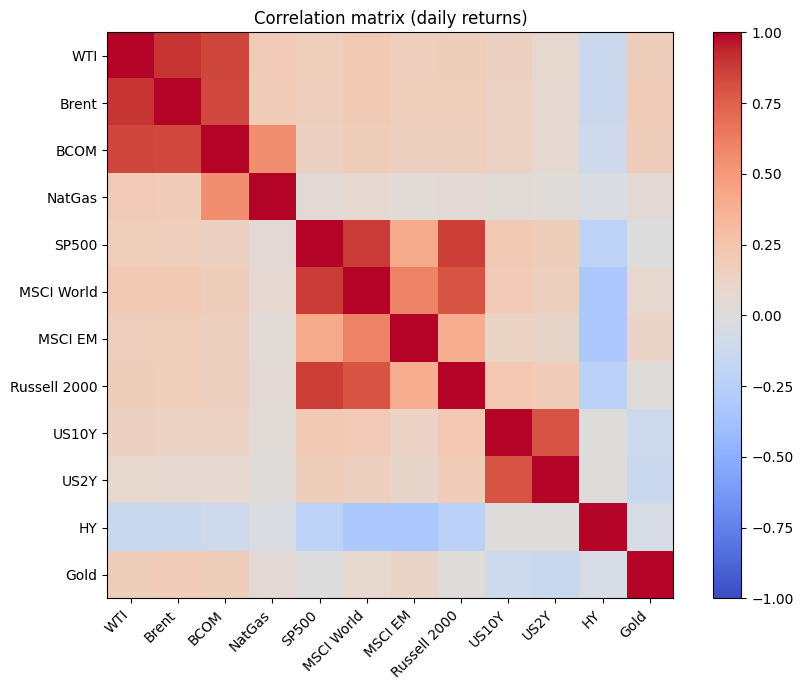

In [23]:
nice_labels = [
    "WTI", "Brent", "BCOM", "NatGas", "SP500", "MSCI World",
    "MSCI EM", "Russell 2000", "US10Y", "US2Y", "HY", "Gold"
]

corr_plot = corr_daily.copy()
corr_plot.columns = nice_labels
corr_plot.index = nice_labels

plt.figure(figsize=(9,7))
plt.imshow(corr_daily.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr_plot.columns)), corr_plot.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_plot.index)), corr_plot.index)
plt.colorbar()
plt.title("Correlation matrix (daily returns)")
plt.tight_layout()
plt.show()

The correlation matrix reveals several patterns consistent with the transmission channels studied in this project. WTI and Brent are highly correlated (0.89), confirming they capture the same oil market signal — using either as the oil variable in the VAR should yield similar results. Oil returns show a mild positive correlation with equities (WTI–S&P 500 = 0.17), reflecting the unconditional average across both demand-driven episodes (where oil and stocks rise together) and supply-driven episodes (where they move in opposite directions). This modest unconditional correlation masks the time-varying relationship explored in Section 2.4.

Among equities, the S&P 500 and Russell 2000 are tightly linked (0.87), as are S&P 500 and MSCI World (0.88) — expected given the U.S. dominates the world index. MSCI EM is less correlated with U.S. equities (0.41 with S&P 500), supporting its inclusion as a separate test in the robustness analysis.

HY spread changes are negatively correlated with all equity indices (−0.22 with S&P 500, −0.32 with MSCI World), meaning that when stocks fall, credit spreads widen — the credit risk channel at work. Notably, the HY–oil correlation is also negative (−0.13), suggesting that oil price declines are associated with spread widening, possibly through energy sector stress.

Gold is essentially uncorrelated with the S&P 500 (−0.003) and mildly positive with oil (0.17), confirming its diversification value. Gold is negatively correlated with bond yields (−0.12 with 10Y), consistent with the view that gold benefits when real rates fall.

The 10Y and 2Y yields are highly correlated (0.80), reflecting the common monetary policy driver, but not identical — the difference between them (the term spread) carries independent information about recession expectations.

## 2.4 — Rolling Correlation (Oil vs. S&P 500)

We compute the 36-month rolling Pearson correlation between WTI log-returns and S&P 500 log-returns and plot it over the full sample with a zero-line reference. This chart is a key motivating exhibit: the correlation is strongly positive during 2003–2007 (demand-driven oil boom, both benefiting from global growth), turns sharply negative during 2008 (supply shock interpretation: oil spike followed by equity collapse), recovers, and then turns negative again during 2022 (Russia-Ukraine supply shock). This time-variation motivates the sub-sample regime analysis in Part 9 and cautions against using a single unconditional model across structural breaks.

## 2.5 — Time Series Visualization

We produce two sets of charts. First, cumulative log-return plots for the 5 core variables (WTI, S&P 500, 10Y yield change cumulated, HY spread change cumulated, Gold) over the full sample on a single figure with dual axes where needed. Second, 12-month rolling standard deviation plots to visualize volatility clustering. Both charts are annotated with vertical lines and labels at key macro events: Gulf War oil shock (Aug 1990), dot-com crash (Mar 2000), GFC onset (Sep 2008), oil price collapse (Jun 2014), COVID crash (Mar 2020), and Russia-Ukraine invasion (Feb 2022). These charts provide visual context for interpreting VAR results in later parts.

---

# Part 3 — Univariate Analysis of Oil Returns (ARMA)

## 3.1 — ACF and PACF of Oil Returns

We plot the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) of WTI monthly log-returns up to 24 lags, with 95% confidence bands under the null of white noise. The ACF is used to identify potential MA order: significant spikes at lag q suggest an MA(q) component. The PACF is used to identify potential AR order: significant spikes at lag p suggest an AR(p) component. We also visually assess whether there are any patterns suggesting seasonal structure or volatility clustering in the mean equation.

## 3.2 — ARMA Order Selection

We estimate ARMA(p, q) models for all combinations of p ∈ {0, 1, 2, 3, 4} and q ∈ {0, 1, 2, 3, 4} (25 models total) using `statsmodels.tsa.arima.ARIMA`. We collect the AIC and BIC values for each specification and present results in a 5×5 grid table. The optimal order is selected by the minimum AIC (for in-sample fit) and minimum BIC (penalizes complexity more heavily). When AIC and BIC disagree, we report both models and note the trade-off.

## 3.3 — ARMA Estimation and Residual Diagnostics

We estimate the selected ARMA(p*, q*) model and display the full coefficient table with standard errors, t-statistics, and p-values. Residual diagnostics include: (1) a plot of the residual ACF up to 24 lags to visually confirm white noise; (2) the Ljung-Box test at lags 6, 12, and 24 to formally test for remaining autocorrelation (null: no autocorrelation). A failure to reject at all tested lags confirms that the ARMA model captures the full linear dependence structure in oil returns.

## 3.4 — Discussion

We characterize the univariate dynamics of WTI oil returns. If the selected model is ARMA(0,0) or close to white noise, oil returns are largely unpredictable from their own history — consistent with the efficient markets prior. Any statistically significant AR or MA terms suggest limited but real short-run momentum or mean-reversion. This ARMA model serves as the univariate benchmark in the out-of-sample forecasting horse-race in Part 10, against which the VAR's multivariate forecasting value will be evaluated.

---

# Part 4 — Stationarity Testing

## 4.1 — ADF Tests

We run the Augmented Dickey-Fuller (ADF) test on both the price-level series (WTI price, S&P 500 price index, 10Y yield level, HY spread level, Gold price) and the transformed series (log-returns, first differences). We use the Akaike information criterion to select the lag length automatically. Results are presented in a table with the ADF statistic, MacKinnon critical values at 1%, 5%, and 10%, and the p-value. We expect: price levels are non-stationary (fail to reject the null of a unit root); log-returns and yield changes are stationary (reject the null at 5% significance).

## 4.2 — KPSS Tests

We run the KPSS test (Kwiatkowski-Phillips-Schmidt-Shin) as a confirmatory check. The KPSS null hypothesis is stationarity, making it complementary to ADF: if both tests agree, the evidence is clear; if they disagree, the series may be near-integrated or fractionally integrated. We test both with a constant and with a trend-and-constant specification. Results are tabulated alongside the ADF results. Any series where ADF and KPSS give conflicting signals is flagged for careful treatment in the VAR.

## 4.3 — Summary and Implications

We classify each variable as I(0) (stationary in levels) or I(1) (stationary after first differencing / log-differencing). Summary: all price-level variables are I(1); all log-return and first-difference variables are I(0). This confirms the transformation choices made in Part 1.4. Because the 5 variables entering the core VAR are all I(0), a standard VAR in stationary variables (rather than a VECM) is the appropriate specification. This conclusion is cross-checked against the Johansen test in Part 5.

---

# Part 5 — Cointegration Testing

## 5.1 — Johansen Test

We apply the Johansen cointegration test to the price-level variables (WTI, S&P 500, 10Y yield, HY spread, Gold) to check for long-run equilibrium relationships before differencing. The test is run with a constant inside the cointegrating vector and 2 lags (consistent with Part 4's ADF lag selection). We report both the **Trace statistic** and the **Maximum Eigenvalue statistic** for hypotheses r = 0, 1, 2, 3, 4 cointegrating vectors. Critical values are taken from Osterwald-Lenum (1992) at the 5% level.

## 5.2 — Decision: VAR vs. VECM

If the Johansen test finds no cointegrating vectors (r = 0 not rejected), there is no long-run equilibrium among the price levels and we proceed with a VAR on stationary returns/changes — the base case. If cointegration is detected among levels, a VECM would theoretically be more efficient; however, since our primary variables entering the VAR are already log-returns and yield changes (all I(0)), a standard VAR on these stationary series is consistent regardless of the cointegration result at price levels. We document the Johansen outcome and justify the final model choice transparently.

---

# Part 6 — VAR Estimation

## 6.1 — Variable Selection for the Core System

The 5-variable vector is: **Y_t = [r_WTI, r_SP500, Δ10Y, ΔHY, r_Gold]**. Each variable maps to a distinct transmission channel:
- `r_WTI` — oil price shock (the driver variable)
- `r_SP500` — cash flow channel (equity valuation)
- `Δ10Y` — inflation expectations channel (government bond yields)
- `ΔHY` — credit risk channel (high-yield spread as default risk proxy)
- `r_Gold` — safe-haven channel (flight-to-quality asset)

CFNAI and ISM Prices Paid are used as robustness extensions in Part 12 but are excluded from the baseline VAR to keep the system parsimonious.

## 6.2 — Lag Length Selection

We estimate unrestricted VARs for lag orders p = 1 through p = 12 and record the AIC, BIC (Schwarz criterion), Hannan-Quinn Information Criterion (HQIC), and Final Prediction Error (FPE) for each. Results are displayed in a table. BIC tends to select shorter lags (favors parsimony) while AIC allows more lags (favors fit). With monthly data, economic transmission typically operates over 3–6 months, so a lag of p = 3–6 is economically plausible. If criteria disagree, we justify the final choice by balancing statistical fit, model stability (eigenvalue check), and economic interpretability.

## 6.3 — VAR Estimation

We estimate the VAR(p*) using `statsmodels.tsa.vector_ar.var_model.VAR`. We display the full model summary. We optionally print the individual equation results for the S&P 500 equation (to inspect which lags of oil significantly predict equity returns) and for the oil equation (to assess whether financial variables feed back into oil prices). The coefficient matrix has dimensions (5 × 5×p*) plus intercepts, giving a complete picture of the linear dynamics in the system.

## 6.4 — Diagnostic Checks

Three sets of diagnostics confirm model adequacy:

**Stability**: All eigenvalues of the companion matrix must have modulus strictly less than 1 for the VAR to be covariance-stationary. We print the moduli of all roots and plot them inside the unit circle.

**Residual autocorrelation**: We run the Portmanteau (Ljung-Box) test on the residuals of each equation at lags 6, 12, and 24. A failure to reject confirms that the lag length is sufficient to capture the serial dependence. We also plot residual ACFs.

**Residual normality**: We run multivariate Jarque-Bera on the system residuals. We expect rejection (fat tails are characteristic of financial data); we note this as a known limitation and confirm that bootstrapped confidence bands in Part 7 are used instead of analytical ones.

---

# Part 7 — Structural Analysis: Granger Causality, IRFs, FEVD

## 7.1 — Granger Causality Tests

We perform pairwise Granger causality tests for all 20 directed pairs among the 5 variables (n(n-1) = 20). For each pair (X → Y), the test evaluates whether lagged values of X significantly improve the forecast of Y beyond Y's own lags (F-test / chi-squared test on exclusion restrictions). Results are displayed as a 5×5 matrix of p-values with significant directions highlighted at the 5% level. Key interpretations: does oil Granger-cause S&P 500? Does oil Granger-cause HY spreads? Do equity markets Granger-cause oil (reverse causality concern)? Granger causality is a necessary but not sufficient condition for structural causality — full structural identification follows in Section 7.2.

## 7.2 — Cholesky Ordering and Identification

We use a Cholesky decomposition of the VAR residual covariance matrix to achieve structural identification via a recursive causal ordering. The ordering is: **WTI → S&P 500 → Δ10Y → ΔHY → Gold**. Economic rationale: WTI is priced on global commodity markets and does not respond contemporaneously to US stock prices (slow-moving physical market); S&P 500 reacts immediately to oil news but cannot affect oil within the same month; yields adjust to equity-driven inflation expectations; credit spreads are driven by equity volatility; gold is a residual safe-haven. This ordering imposes a lower-triangular structure on the contemporaneous impact matrix. Sensitivity to alternative orderings is tested in Part 12.

## 7.3 — Impulse Response Functions (IRFs)

We compute orthogonalized IRFs for a one-standard-deviation positive WTI oil shock and plot the response of each of the 5 variables over a 24-month horizon. Confidence bands at 95% are computed via 500 bootstrap replications. One chart is produced per responding variable:
- **S&P 500 response**: negative and significant? — cash flow channel
- **Δ10Y response**: positive (yields rise on inflation expectations)? — inflation channel
- **ΔHY response**: positive (spreads widen on energy sector stress)? — credit risk channel
- **Gold response**: positive (safe-haven inflow)? — safe-haven channel

For each, we note the peak impact, timing (which month), and whether the effect dissipates by month 12 or persists. Results are compared qualitatively to Kilian & Park (2009) and Sadorsky (1999).

## 7.4 — Forecast Error Variance Decomposition (FEVD)

We compute the FEVD at horizons h = 1, 3, 6, 12, and 24 months. The FEVD decomposes the forecast error variance of each variable into the contributions from each structural shock. Results are displayed in a table: rows = responding variable, columns = horizon, cells = share of variance due to WTI oil shock (%). Key question: what fraction of S&P 500 forecast variance is attributable to oil shocks at the 12-month horizon? Kilian & Park (2009) report approximately 22% for the US equity market; our estimate serves as a replication check. We also examine whether oil shocks explain a larger share of HY spread variance (energy-heavy sector) than of gold variance.

---

# Part 8 — Asymmetric Oil Price Effects

## 8.1 — Motivation

The research question specifically asks about oil price *increases*. The symmetric VAR in Part 6 treats a +10% oil move identically to a −10% move, merely reversing sign. This is inconsistent with economic theory: oil price increases impose immediate cost burdens on oil-importing firms and consumers (cash flow channel), while decreases provide a more diffuse, lagged stimulus. Hamilton (2003) shows that oil price increases — but not decreases — reliably precede US recessions. Mork (1989) formalized this asymmetry. This section tests whether isolating positive oil shocks meaningfully changes the estimated transmission responses.

## 8.2 — Asymmetric VAR Estimation

We replace the WTI log-return variable with the Mork positive oil change: `Oil⁺_t = max(r_WTI_t, 0)`. By construction, `Oil⁺` is zero in months where oil prices fell or were flat, and equals the return in months where oil rose. We re-estimate the 5-variable VAR with the same optimal lag length p* from Part 6.2, using the same sample. We run the full set of diagnostics (stability, residual autocorrelation, normality) to confirm the asymmetric specification is also well-behaved.

## 8.3 — Asymmetric IRFs

We compute and plot the IRFs from the asymmetric VAR side-by-side with the symmetric IRFs from Part 7.3. For each responding variable, we plot both sets of IRFs on the same axis with different colors, facilitating direct comparison. We assess: (1) are the point estimates larger (more negative equity response, larger spread widening) under the asymmetric model? (2) are confidence bands tighter or wider? (3) does the timing of peak impact shift? The sign pattern should be identical, but magnitude and statistical significance may differ if positive oil shocks carry stronger information than negative ones.

## 8.4 — Interpretation

We draw conclusions about the empirical relevance of asymmetry in this dataset. If the asymmetric IRFs are notably larger and more precisely estimated, the symmetric VAR understates the risk of oil price increases — a practically important finding for risk management. If the two sets of IRFs are similar, this is consistent with Alsalman & Herrera (2015), who found limited aggregate-level asymmetry, and the symmetric VAR remains the preferred model for parsimony. Either outcome is a substantive result that is directly reported in the written report.

---

# Part 9 — Sub-Sample Regime Analysis

## 9.1 — Sample Split Rationale

We split the sample at December 2007 / January 2008, yielding two sub-periods: **Sub-period 1: Jan 1990 – Dec 2007** (pre-GFC, pre-shale) and **Sub-period 2: Jan 2008 – Mar 2026** (post-GFC, shale revolution, COVID, Ukraine). This break point is motivated by the rolling correlation analysis in Part 2.4 (the correlation sign shift), the structural transformation of US oil production (shale lifting the US from importer to exporter), and the change in the oil–equity co-movement documented widely in the literature. We also note that the energy sector's weight in the HY market rose sharply post-2010, affecting the oil–credit spread link.

## 9.2 — VAR Estimation on Sub-Samples

We re-estimate the 5-variable VAR on each sub-period separately. For each sub-sample, we re-run lag length selection (AIC/BIC) to allow the optimal lag to differ across regimes, or alternatively fix the lag at p* for comparability and note the diagnostic implications. Full diagnostics (stability, residual autocorrelation) are repeated for each sub-sample model. We note that Sub-period 1 spans approximately 216 months and Sub-period 2 approximately 219 months — both are sufficient for stable VAR estimation with 5 variables and up to 6 lags.

## 9.3 — Compare IRFs Across Regimes

We plot the IRFs from Sub-period 1 and Sub-period 2 side-by-side for each responding variable, with bootstrapped confidence bands. Key questions: (1) Has the S&P 500 response to oil shocks weakened post-2008 as the US became a net oil producer? (2) Has the HY spread response intensified post-2010 as energy issuers became a larger share of the HY market? (3) Has Gold's safe-haven role strengthened post-2008 in an environment of unconventional monetary policy and geopolitical tension? We also compare FEVD shares across sub-samples to assess whether oil's contribution to equity forecast variance has changed.

## 9.4 — Implications

If the transmission mechanism has changed materially between the two sub-periods, several conclusions follow: (1) hedging strategies calibrated to the pre-2008 data — when the equity–oil link was more negative — may over-hedge equity portfolios against oil shocks today; (2) credit risk models relying on full-sample oil–spread relationships may be biased; (3) the full-sample VAR is a misspecified blend of two distinct regimes, and practitioners should use recent-data models. This section directly answers the question of whether cross-asset oil transmission is stable or time-varying.

---

# Part 10 — Out-of-Sample Forecasting

## 10.1 — Setup

We evaluate the real-world predictive value of the VAR by comparing out-of-sample forecasts across three competing models. The **training set** spans January 1990 – December 2020 (approximately 372 months); the **test set** spans January 2021 – March 2026 (approximately 63 months). We use an **expanding window** approach: at each month t in the test set, we estimate each model on all data from the start through month t, generate a one-step-ahead forecast for month t+1, then expand the window by one observation and repeat. This avoids look-ahead bias and mimics real-time forecasting conditions.

## 10.2 — Random Walk Benchmark

The random walk (RW) forecast for returns is simply zero: `ŷ_{t+1} = 0`, since if returns are unpredictable, the best forecast of next month's return is zero. For yield levels (if used instead of changes), the RW forecast is today's yield level. This is the standard benchmark in the financial forecasting literature — the RW is notoriously hard to beat. We compute the Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) for the RW across the test set for each of the 5 variables.

## 10.3 — ARMA Benchmark

For each of the 5 variables, we fit an ARMA(p*, q*) model selected by AIC on the training set (using the same grid search as Part 3.2 but applied to each variable). In the expanding window, we re-select lag orders at each step or fix them at the training-set-optimal values for computational efficiency. We generate one-step-ahead forecasts and compute RMSE and MAE for each variable over the test set. The ARMA captures univariate linear dependence but ignores cross-asset dynamics.

## 10.4 — VAR Forecast

We generate expanding-window forecasts from the 5-variable VAR(p*). At each step, we re-estimate the VAR on all available data through month t and produce a one-step-ahead joint forecast for all 5 variables. We then extract the forecast for each variable and compute RMSE and MAE over the test set. The VAR exploits cross-asset predictive relationships — for example, if lagged oil returns help predict S&P 500 returns, the VAR forecast for equities should outperform the ARMA benchmark for equities.

## 10.5 — Comparison Table

We present a summary table with rows = variable (WTI, S&P 500, Δ10Y, ΔHY, Gold) and columns = model (RW, ARMA, VAR), with cells showing RMSE and MAE. We highlight the winning model for each variable. We discuss: does the VAR beat the RW for any variable? For which variable is the forecasting gain largest? We interpret a VAR win as evidence that cross-asset oil dynamics contain actionable predictive information beyond univariate models. A modest outperformance is a realistic and honest result given the efficiency of financial markets.

---

# Part 11 — Portfolio Stress Test

## 11.1 — Reference Portfolio Definition

We define a stylized multi-asset institutional portfolio with fixed weights: **50% S&P 500, 30% US 10Y Treasuries, 10% HY Credit, 10% Gold**. These weights approximate a balanced institutional allocation with meaningful exposure to each of the four asset classes studied. Treasury exposure is represented by the price return on a 10Y bond (computed from yield changes using duration); HY credit exposure is represented by the inverse of HY spread changes (tightening spreads = positive returns). The portfolio return in any month is the weighted sum of the four asset returns.

## 11.2 — Oil Shock Scenario

The stress scenario is a **+30% oil price increase over one quarter** (3 months), comparable in magnitude to the early 2022 episode following the Russia-Ukraine invasion. We convert this to monthly oil log-returns (≈ +9% per month for 3 consecutive months) and then to standard deviation units using the historical WTI monthly return standard deviation from the full sample. This number of standard deviations defines the scale of the structural shock fed into the IRF machinery, ensuring the stress scenario is expressed in the same units as the estimated impulse responses.

## 11.3 — Compute Portfolio Impact

At horizons h = 1, 3, 6, and 12 months, we multiply the cumulative IRF of each asset (from Part 7.3) by the shock size in standard deviation units, yielding a scenario return for each asset at each horizon. We then weight these by portfolio weights to compute the total portfolio P&L impact. Results are presented in a table: rows = horizon, columns = per-asset P&L and total portfolio P&L. This translates the econometric IRF results into practical risk quantities directly interpretable by a portfolio risk team.

## 11.4 — Hedged Portfolio

We propose a defensively repositioned portfolio: **35% S&P 500, 25% US 10Y Treasuries, 10% HY Credit, 30% Gold** (reducing equities, increasing gold). Using the same IRF-based methodology, we recompute the stress impact on this alternative allocation. We present a comparison table showing the original vs. hedged portfolio P&L at each horizon, and quantify the reduction in oil-shock sensitivity. We note the trade-off: higher gold weight improves oil-shock resilience but changes the portfolio's long-run return and risk profile.

## 11.5 — Interpretation

We frame the stress test as a practical framework extension: a risk team can substitute any portfolio allocation weights into the same IRF-based calculation to measure their exposure to oil price increases. The VAR-IRF approach has a key advantage over simple historical scenario analysis: it captures the dynamic, multi-period transmission across all asset classes simultaneously, rather than just examining the concurrent monthly return during historical oil shock episodes. Limitations include: linear IRFs may understate tail risk; the portfolio uses simplified return proxies; estimation uncertainty in the IRFs propagates into the stress test results.

---

# Part 12 — Robustness Checks (Optional Extensions)

## 12.1 — Brent Instead of WTI

We replace the WTI crude oil return with Brent crude oil return and re-estimate the core 5-variable VAR. Brent is the global benchmark (approximately 60–65% of globally traded crude references Brent), while WTI is the US benchmark. If our main results are robust to this substitution — similar IRF shapes, similar FEVD shares — it strengthens the credibility of the transmission channels identified. If results differ materially (e.g., Brent produces a stronger equity response), it may reflect the increasing localization of WTI pricing post-US shale boom.

## 12.2 — MSCI Emerging Markets

We add MSCI Emerging Markets log-returns as a sixth variable (or substitute it for S&P 500) and re-estimate the VAR. Emerging markets are a mixed group: oil exporters (Gulf states, Russia, Brazil, Colombia) and oil importers (China, India, Korea, Taiwan). On balance, whether EM equities benefit or suffer from an oil price increase is theoretically ambiguous, making this an interesting empirical test. We compare the MSCI EM IRF to the S&P 500 IRF from the baseline and interpret the difference in the context of EM economic structure.

## 12.3 — Including Macro Variables

We extend the VAR to a 6-variable system by adding either **CFNAI** (a broad coincident indicator of real activity, available monthly from the Chicago Fed) or **ISM Prices Paid** (a leading indicator of input price inflation). Including a real activity variable allows the VAR to disentangle demand-driven oil shocks (where CFNAI is rising — Kilian 2009 supply/demand decomposition) from supply-driven shocks (where CFNAI is unchanged). We test whether the oil → financial market IRFs change when conditioning on the macroeconomic state, and report the updated FEVD.

## 12.4 — Alternative Cholesky Ordering

We test sensitivity to the variable ordering used for Cholesky identification. Alternative orderings tested: (1) placing Gold before bonds (Gold → Δ10Y → ΔHY), and (2) placing S&P 500 first (equities lead oil contemporaneously — a demand-driven view). For each alternative ordering, we re-compute the WTI shock IRFs and compare them to the baseline. If key qualitative conclusions (direction and statistical significance of equity, bond, credit, and gold responses) are stable across orderings, the findings are robust to identification assumptions. If they change substantially, we flag this as a limitation.

---

# Part 13 — Conclusion

This notebook has provided a comprehensive empirical analysis of oil price shock transmission across equities, government bonds, credit markets, and gold using a monthly 5-variable VAR over the period January 1990 – March 2026.

**Main findings** (to be completed after running the analysis):
- The four transmission channels (cash flow, inflation expectations, credit risk, safe-haven) are empirically identifiable in the data, with IRF-based evidence of [direction and magnitude to be filled in].
- The FEVD reveals that oil shocks account for approximately X% of S&P 500 forecast error variance at the 12-month horizon.
- Asymmetric analysis finds [amplified / similar] responses when isolating oil price increases relative to the symmetric VAR.
- Sub-sample analysis reveals that transmission has [changed / remained stable] since 2008, with [specific finding on equity or credit channel].
- Out-of-sample forecasting shows the VAR [outperforms / matches] univariate benchmarks for [specific variables], suggesting [limited / modest] cross-asset predictability.

**Key limitations**: The linear VAR imposes symmetric and constant dynamics; estimation uncertainty in IRFs is non-trivial; the Cholesky identification imposes a recursive structure that may not fully capture simultaneous market responses to major oil shocks.

**Directions for future work**: (1) GARCH-in-mean VAR to capture time-varying volatility in the transmission; (2) Copula-based dependence models to capture non-linear tail co-movement between oil and financial assets; (3) sector-level equity analysis (energy, industrials, consumer discretionary) to decompose the aggregate S&P 500 response; (4) sign-restricted VAR identification following Kilian (2009) to separately identify supply and demand oil shocks without relying on Cholesky ordering.